In [1]:
import pandas as pd
test_data = pd.read_csv(r'C:\Users\Lina\Downloads\ab_test_data.csv')

In [2]:
test_data.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [3]:
test_data.describe(include = 'all')

,user_id,timestamp,test_group,conversion
count,19998,19998,19998,19998.000000
unique,19998,19998,2,NaN
top,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,NaN
freq,1,1,10013,NaN
mean,NaN,NaN,NaN,0.075008
std,NaN,NaN,NaN,0.263410
min,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,0.000000


In [4]:
test_data.groupby('test_group').describe()

conversion                                             
                count      mean       std  min  25%  50%  75%  max
test_group                                                        
a             10013.0  0.061021  0.239380  0.0  0.0  0.0  0.0  1.0
b              9985.0  0.089034  0.284806  0.0  0.0  0.0  0.0  1.0

In [5]:
# Підрахунок кількості користувачів та конверсій для кожної групи
user_counts = test_data['test_group'].value_counts()  # кількість користувачів у кожній групі
conversion_counts = test_data.groupby('test_group')['conversion'].sum()  # кількість конверсій у кожній групі
# Рівень конверсії для кожної групи
conversion_rates = conversion_counts / user_counts

# Виведення результатів
print(f"Кількість користувачів у групі A: {user_counts['a']}")
print(f"Кількість користувачів у групі B: {user_counts['b']}")
print(f"Кількість конверсій у групі A: {conversion_counts['a']}")
print(f"Кількість конверсій у групі B: {conversion_counts['b']}")
print(f"Рівень конверсії у групі A: {conversion_rates['a']:.4f}")
print(f"Рівень конверсії у групі B: {conversion_rates['b']:.4f}")

Кількість користувачів у групі A: 10013
Кількість користувачів у групі B: 9985
Кількість конверсій у групі A: 611
Кількість конверсій у групі B: 889
Рівень конверсії у групі A: 0.0610
Рівень конверсії у групі B: 0.0890


In [6]:
# Переводимо стовпець 'event_timestamp' у формат дати та часу
test_data['timestamp'] = pd.to_datetime(test_data['timestamp'])

# Знаходимо найранішу та найпізнішу дату
start_date = test_data['timestamp'].min()
end_date = test_data['timestamp'].max()

# Обчислюємо тривалість тесту в днях
test_duration = (end_date - start_date).days

print(f"Дата початку тесту: {start_date.strftime('%Y-%m-%d')}")
print(f"Дата кінця тесту: {end_date.strftime('%Y-%m-%d')}")
print(f"Тривалість тесту (дні): {test_duration}")

Дата початку тесту: 2023-07-03
Дата кінця тесту: 2023-07-25
Тривалість тесту (дні): 21


In [26]:
# Проводимо тестування за Критерієм Стʼюдента
from scipy import stats

alpha = 0.05
a = test_data[test_data['test_group'] == 'a']['conversion']
b = test_data[test_data['test_group'] == 'b']['conversion']
statistic, pvalue = stats.ttest_ind(a, b, alternative='two-sided')
print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')
    # виходячи із розрахунків, ми можемо відхилити нульову гіпотезу

t-statistic: -7.53, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


In [28]:
# Проводимо тестування за Критерієм Хі-квадрат
from scipy import stats

alpha = 0.05

observed = pd.crosstab(test_data['test_group'].values, test_data['conversion'].values)
statistic, pvalue, dof, expected_values = stats.chi2_contingency(observed)

print(f't-statistic: {round(statistic, 2)}, p-value: {round(pvalue, 2)}')

if pvalue < alpha:
    print('The difference is statistically significant, Null Hypothesis is rejected.')
else:
    print('The difference is insignificant, Null Hypothesis cannot rejected.')

t-statistic: 56.14, p-value: 0.0
The difference is statistically significant, Null Hypothesis is rejected.


In [ ]:
# виходячи із запропонованих даних, кращим вибором буде тестування за Критерієм Хі-квадрат

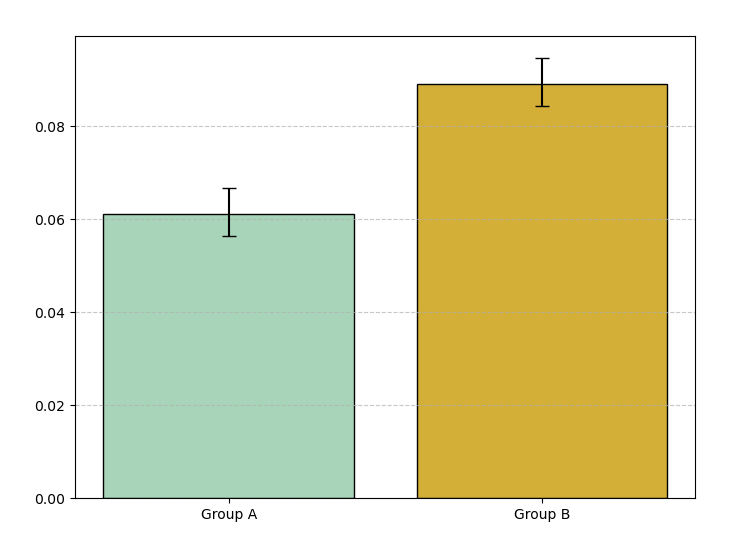

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Розраховуємо середні значення для кожної групи
mean_a = test_data[test_data['test_group'] == 'a']['conversion'].mean()
mean_b = test_data[test_data['test_group'] == 'b']['conversion'].mean()

# Розраховуємо довірчі інтервали для кожної групи (95%)
conf_int_a = stats.t.interval(0.95, len(test_data[test_data['test_group'] == 'a']['conversion'])-1,
                              loc=mean_a, scale=stats.sem(test_data[test_data['test_group'] == 'a']['conversion']))

conf_int_b = stats.t.interval(0.95, len(test_data[test_data['test_group'] == 'b']['conversion'])-1,
                              loc=mean_b, scale=stats.sem(test_data[test_data['test_group'] == 'b']['conversion']))

# Підготовка даних для візуалізації
means = [mean_a, mean_b]
lower_bounds = [conf_int_a[0], conf_int_b[0]]
upper_bounds = [conf_int_a[1], conf_int_b[1]]
groups = ['Group A', 'Group B']

# Визначення кольорів
colors = ['#A8D5BA', '#D4AF37']  # Ніжно-зелений та золотий

# Створення стовпчикової діаграми
plt.figure(figsize=(8, 6))
plt.bar(groups, means, yerr=[(means[i] - lower_bounds[i], upper_bounds[i] - means[i]) for i in range(len(groups))],
        capsize=5, color=colors, edgecolor='black')

# Заголовок і налаштування шрифтів
plt.title('Порівняння середніх значень з 95% довірчими інтервалами', fontsize=16, color='white')
plt.xlabel('Група тесту', fontsize=14, color='white')
plt.ylabel('Середнє значення конверсії', fontsize=14, color='white')

# Налаштування сітки
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Збереження та відображення графіка
plt.savefig(r'C:\Users\Lina\Desktop\my homework\Середнє значення конверсії.png')

plt.show()



In [9]:
import numpy as np

# Кількість бутстрепів
n_bootstraps = 1000

# Масив для збереження середніх значень
bootstrap_means_a = []
bootstrap_means_b = []

# Генерація бутстрепів для кожної групи
for _ in range(n_bootstraps):
    sample_a = test_data[test_data['test_group'] == 'a']['conversion'].sample(frac=1, replace=True)
    sample_b = test_data[test_data['test_group'] == 'b']['conversion'].sample(frac=1, replace=True)
    
    bootstrap_means_a.append(sample_a.mean())
    bootstrap_means_b.append(sample_b.mean())

# Перетворюємо в масиви
bootstrap_means_a = np.array(bootstrap_means_a)
bootstrap_means_b = np.array(bootstrap_means_b)

# Виведення середніх значень
print(f"Середні значення для групи A (бутстрепінг): {bootstrap_means_a[:5]}...")  # Вивести перші 5 значень
print(f"Середні значення для групи B (бутстрепінг): {bootstrap_means_b[:5]}...")


Середні значення для групи A (бутстрепінг): [0.06301808 0.06062119 0.06112054 0.06142015 0.0619195 ]...
Середні значення для групи B (бутстрепінг): [0.08783175 0.08622934 0.0895343  0.0877316  0.089334  ]...


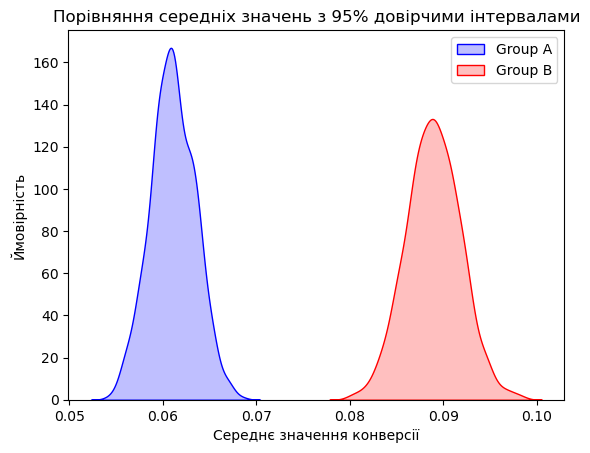

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Побудова графіка порівняння середніх значень
sns.kdeplot(bootstrap_means_a, fill=True, label="Group A", color="blue")
sns.kdeplot(bootstrap_means_b, fill=True, label="Group B", color="red")

# Налаштування заголовку та підписів
plt.title('Порівняння середніх значень з 95% довірчими інтервалами')
plt.xlabel('Середнє значення конверсії')
plt.ylabel('Ймовірність')

# Додавання легенди
plt.legend()

# Виведення графіка
plt.show()


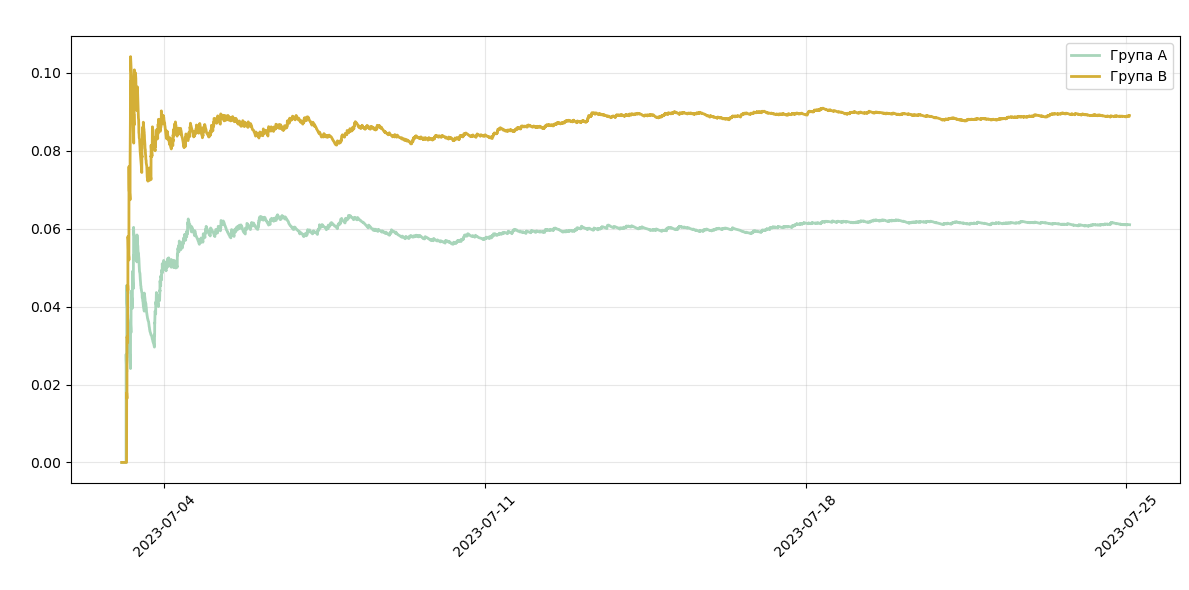

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Розрахунок кумулятивних значень для груп A та B
comulative_metric_a = test_data[test_data['test_group'] == 'a'].sort_values(by='timestamp')['conversion'].expanding().mean().reset_index(drop=True)
comulative_metric_b = test_data[test_data['test_group'] == 'b'].sort_values(by='timestamp')['conversion'].expanding().mean().reset_index(drop=True)

# Визначення кольорів для ліній
color_a = '#A8D5BA'  # Ніжно-зелений
color_b = '#D4AF37'  # Золотий

plt.figure(figsize=(12, 6))

# Побудова графіків для груп A і B
plt.plot(dates_a, comulative_metric_a, label='Група A', color=color_a, linewidth=2)
plt.plot(dates_b, comulative_metric_b, label='Група B', color=color_b, linewidth=2)

# Форматування осі X для дат
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))  

# Заголовок і підписи осей
plt.title('Зміна середнього рівня конверсії в часі', fontsize=16, color='white')  # Білий заголовок, якщо фон оливковий
plt.xlabel('Дата', fontsize=12, color='white')
plt.ylabel('Рівень конверсії', fontsize=12, color='white')

# Легенда та налаштування сітки
plt.legend()
plt.grid(alpha=0.3)

# Форматування підписів осі X для кращої читабельності
plt.xticks(rotation=45)

# Підлаштування компонувань
plt.tight_layout()

# Збереження графіка
plt.savefig(r'C:\Users\Lina\Desktop\my homework\Зміна середнього рівня конверсії в часі.png')

plt.show()




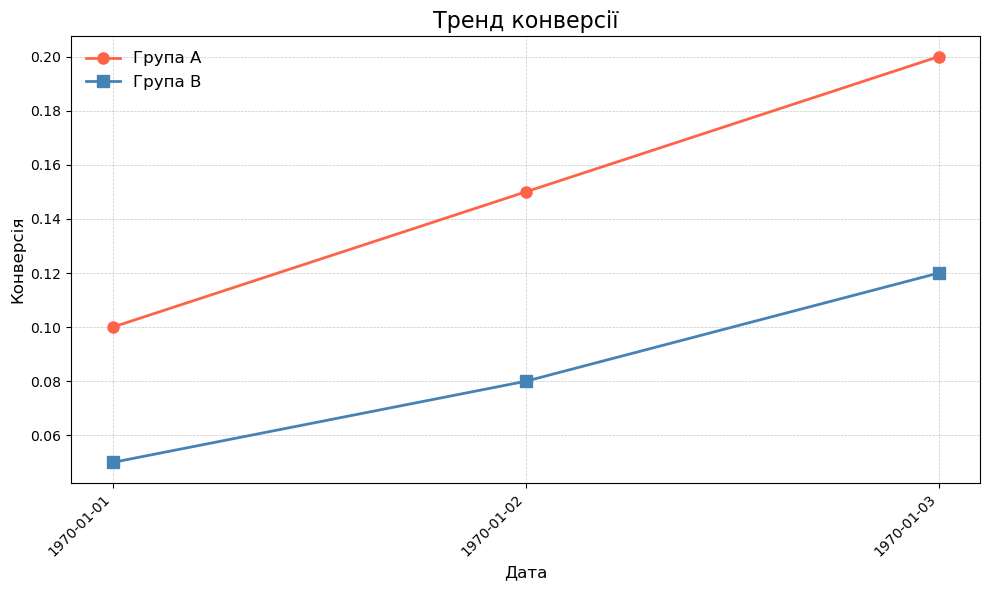

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Данні для графіка
dates = ['2024-01-01', '2024-01-02', '2024-01-03']
values_a = [0.1, 0.15, 0.2]
values_b = [0.05, 0.08, 0.12]

# Графік з лініями для кожної групи
plt.figure(figsize=(10, 6))

# Лінії з маркерами і стилем
plt.plot(dates, values_a, label='Група A', color='#FF6347', marker='o', markersize=8, linestyle='-', linewidth=2)
plt.plot(dates, values_b, label='Група B', color='#4682B4', marker='s', markersize=8, linestyle='-', linewidth=2)

# Додаємо оформлення осей
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.title('Тренд конверсії', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Конверсія', fontsize=12)

# Покращена легенда
plt.legend(loc='best', fontsize=12, frameon=False)

# Сітка та налаштування вигляду
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


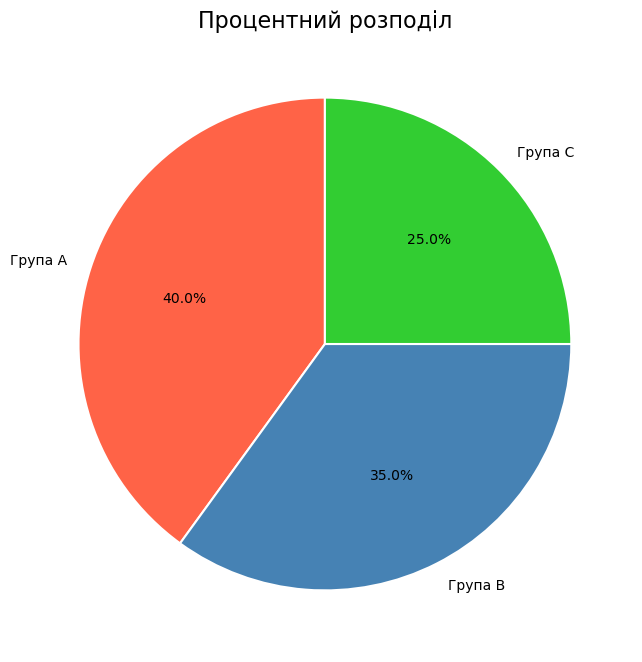

In [44]:
import matplotlib.pyplot as plt

# Данні для графіка
labels = ['Група A', 'Група B', 'Група C']
sizes = [40, 35, 25]

# Створення кругової діаграми з кроками
colors = ['#FF6347', '#4682B4', '#32CD32']

# Кругова діаграма
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'linestyle': 'solid'})

# Стиль для легенди
plt.title('Процентний розподіл', fontsize=16)
plt.show()

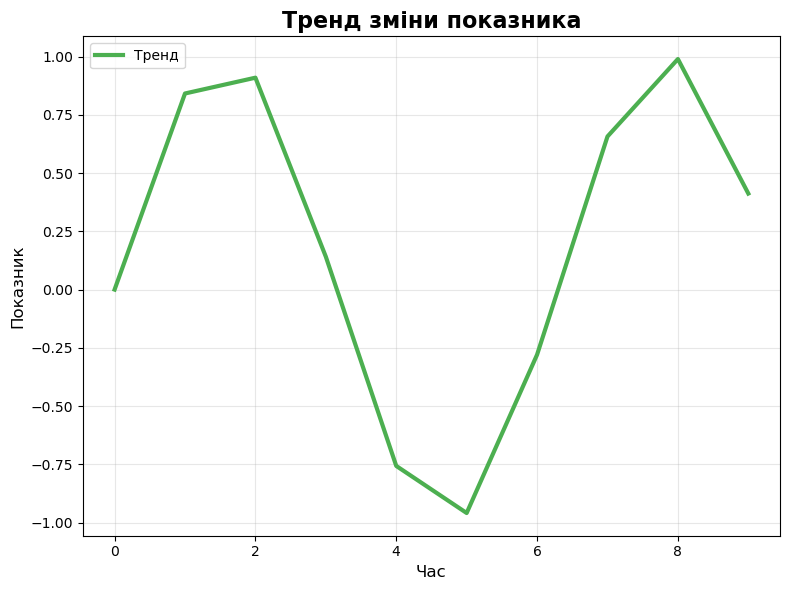

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Мінімальні дані для графіка (неважливо, просто для виду)
x = np.arange(0, 10, 1)
y = np.sin(x)

# Створюємо графік
plt.figure(figsize=(8, 6))

# Лінія тренду
plt.plot(x, y, color='#4CAF50', lw=3, label='Тренд')

# Налаштування графіка
plt.title('Тренд зміни показника', fontsize=16, fontweight='bold')
plt.xlabel('Час', fontsize=12)
plt.ylabel('Показник', fontsize=12)

# Оформлення
plt.legend()
plt.grid(True, alpha=0.3)

# Показати
plt.tight_layout()
plt.show()
